# TransformerQEC: Evaluation & Comparison

Evaluate the transformer decoder against Minimum Weight Perfect Matching (MWPM) across code distances and physical error rates. Produce logical error rate curves and estimate the error correction threshold.

**Pre-requisite:** Run `02_model_and_training.ipynb` for each distance (d=3, 5, 7) to produce checkpoint files (`transformer_qec_d{d}.pkl`).

In [1]:
!pip install -q "stim>=1.14" pymatching flax

In [2]:
import gc
import jax
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import stim
import pymatching
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

print(f'JAX backend: {jax.default_backend()}')

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


JAX backend: tpu


## Model Definition & Data Utilities

Model architecture must match the one used during training to load checkpoint weights correctly.

In [3]:
POS_ENCODING  = "rope" # "default" | "rope"

In [4]:
# --- Model (must match training notebook architecture) ---

# ---------------------------------------------------------------------------
# 2.5D Rotary Position Embedding (RoPE) for QEC space-time coordinates
# ---------------------------------------------------------------------------
# Encodes [x,y] jointly via 2D RoPE and [t] via 1D RoPE into separate
# subspaces of each attention head.  After the standard Q @ K^T dot
# product, the score decomposes as:
#
#   Attention(i,j) ~ Q_{xy,i} . K_{xy,j}  +  Q_{t,i} . K_{t,j}
#
# because the spatial and temporal dimension chunks are orthogonal.
# Each chunk uses RoPE's rotation, so the score depends only on the
# *relative* displacement (dx, dy, dt) â€” translational invariance.
# ---------------------------------------------------------------------------

def _round_even(n):
    """Round to nearest even integer (RoPE needs dimension pairs)."""
    return int(2 * round(n / 2))


def build_rope_2_5d(coords, head_dim, seq_len,
                    spatial_ratio=3, temporal_ratio=1,
                    base_spatial=10000.0, base_temporal=10000.0):
    """Build cos/sin tables for 2.5D RoPE from [x,y,t] coordinates.

    The head dimensions are split into a spatial chunk (2D RoPE on x,y)
    and a temporal chunk (1D RoPE on t) according to the given ratio.

    Args:
        coords:      (L, 3) normalized detector coords [x, y, round].
        head_dim:    int, per-head dimension (must be even).
        seq_len:     int, used to scale [0,1]-normalized coords back to
                     integer-like magnitudes for the frequency spectrum.
        spatial_ratio:  int, relative weight for spatial dims (default 3).
        temporal_ratio: int, relative weight for temporal dims (default 1).
        base_spatial:   float, RoPE frequency base for [x,y] (default 10000).
        base_temporal:  float, RoPE frequency base for [t] (default 10000).

    Returns:
        (rope_cos, rope_sin) each of shape (L, head_dim//2).
    """
    total = spatial_ratio + temporal_ratio
    n_pairs = head_dim // 2  # total rotation-pair count

    # --- dynamic split, forced to even dim counts ---
    n_spatial_dims = _round_even(head_dim * spatial_ratio / total)
    n_spatial_dims = max(2, min(n_spatial_dims, head_dim - 2))  # at least 1 pair each
    n_temporal_dims = head_dim - n_spatial_dims

    n_spatial_pairs = n_spatial_dims // 2
    n_temporal_pairs = n_temporal_dims // 2

    # --- scale coords from [0,1] to integer-like range ---
    x_pos = coords[:, 0] * seq_len   # (L,)
    y_pos = coords[:, 1] * seq_len   # (L,)
    t_pos = coords[:, 2] * seq_len   # (L,)

    # =================================================================
    # Spatial chunk â€” 2D RoPE interleaving x and y
    # =================================================================
    # Allocate half the spatial pairs to x, half to y.  For each axis
    # we compute independent inverse-frequency bands, then interleave
    # the (x, y) angles so nearby spatial pairs encode the two axes at
    # the same frequency scale.  This joint encoding couples (x,y)
    # within the spatial subspace.
    n_x_pairs = n_spatial_pairs // 2
    n_y_pairs = n_spatial_pairs - n_x_pairs  # may be +1 if odd

    # Inverse-frequency bands: theta_i = 1 / base^(2i / n_spatial_dims)
    # Each axis gets its own progression so the frequency spectrum
    # covers the full range independently.
    freq_x = 1.0 / (base_spatial ** (2.0 * jnp.arange(n_x_pairs) / n_spatial_dims))
    freq_y = 1.0 / (base_spatial ** (2.0 * jnp.arange(n_y_pairs) / n_spatial_dims))

    # Outer products: position * frequency -> rotation angles
    angles_x = x_pos[:, None] * freq_x[None, :]   # (L, n_x_pairs)
    angles_y = y_pos[:, None] * freq_y[None, :]   # (L, n_y_pairs)

    # Vectorized interleave: stack + reshape replaces O(n) slice ops with 1 XLA op.
    min_pairs = min(n_x_pairs, n_y_pairs)
    paired = jnp.stack([angles_x[:, :min_pairs],
                        angles_y[:, :min_pairs]], axis=-1)        # (L, min_pairs, 2)
    interleaved = paired.reshape(angles_x.shape[0], min_pairs * 2)  # (L, min_pairs*2)
    # Append any remaining from the longer axis (at most 1 extra pair)
    parts = [interleaved]
    if n_x_pairs > min_pairs:
        parts.append(angles_x[:, min_pairs:])
    if n_y_pairs > min_pairs:
        parts.append(angles_y[:, min_pairs:])
    angles_spatial = jnp.concatenate(parts, axis=-1) if len(parts) > 1 else interleaved

    # =================================================================
    # Temporal chunk â€” standard 1D RoPE on t
    # =================================================================
    freq_t = 1.0 / (base_temporal ** (2.0 * jnp.arange(n_temporal_pairs) / n_temporal_dims))
    angles_temporal = t_pos[:, None] * freq_t[None, :]  # (L, n_temporal_pairs)

    # =================================================================
    # Concatenate spatial + temporal angles -> full (L, n_pairs) table
    # =================================================================
    angles = jnp.concatenate([angles_spatial, angles_temporal], axis=-1)
    return jnp.cos(angles), jnp.sin(angles)


def apply_rope(x, rope_cos, rope_sin):
    """Apply rotary embedding to the last dimension of x.

    Uses the half-split layout (LLaMA-style):
      x = [x_first_half | x_second_half]
    Each corresponding element pair (x_first[i], x_second[i]) is rotated
    by the angle at position i:
      out_first[i]  =  x_first[i] * cos[i]  -  x_second[i] * sin[i]
      out_second[i] =  x_first[i] * sin[i]  +  x_second[i] * cos[i]

    This is mathematically equivalent to the complex-number formulation
    but avoids complex dtypes for XLA compatibility.

    Args:
        x:        (..., head_dim)  â€” Q or K tensor.
        rope_cos: (..., head_dim//2) â€” cosine table (broadcastable).
        rope_sin: (..., head_dim//2) â€” sine table (broadcastable).

    Returns:
        Rotated tensor, same shape as x.
    """
    half = x.shape[-1] // 2
    x1 = x[..., :half]   # first half of dims
    x2 = x[..., half:]   # second half of dims
    out1 = x1 * rope_cos - x2 * rope_sin
    out2 = x1 * rope_sin + x2 * rope_cos
    return jnp.concatenate([out1, out2], axis=-1)


# ---------------------------------------------------------------------------
# Transformer blocks
# ---------------------------------------------------------------------------

class TransformerBlock(nn.Module):
    d_model: int
    num_heads: int
    ffn_dim: int
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, x):
        # Pre-norm multi-head self-attention
        y = nn.LayerNorm(dtype=self.dtype)(x)
        y = nn.MultiHeadDotProductAttention(
            num_heads=self.num_heads, dtype=self.dtype)(y, y)
        x = x + y
        # Pre-norm feed-forward
        y = nn.LayerNorm(dtype=self.dtype)(x)
        y = nn.Dense(self.ffn_dim, dtype=self.dtype)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.d_model, dtype=self.dtype)(y)
        return x + y


class TransformerBlockWithRoPE(nn.Module):
    """Pre-norm transformer block with manual attention for RoPE injection.

    RoPE must be applied to Q and K *after* linear projection but
    *before* the dot product.  Flax's MultiHeadDotProductAttention does
    not expose this hook point, so we project Q/K/V manually via
    DenseGeneral and compute scaled dot-product attention inline.
    """
    d_model: int
    num_heads: int
    ffn_dim: int
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, x, rope_cos, rope_sin):
        """
        Args:
            x:         (B, L, d_model)
            rope_cos:  (L, head_dim//2)  â€” precomputed cos table
            rope_sin:  (L, head_dim//2)  â€” precomputed sin table
        """
        head_dim = self.d_model // self.num_heads

        # --- Pre-norm self-attention with RoPE ---
        y = nn.LayerNorm(dtype=self.dtype)(x)

        # Project to multi-head Q, K, V: (B, L, num_heads, head_dim)
        q = nn.DenseGeneral(features=(self.num_heads, head_dim),
                            axis=-1, dtype=self.dtype, name='query')(y)
        k = nn.DenseGeneral(features=(self.num_heads, head_dim),
                            axis=-1, dtype=self.dtype, name='key')(y)
        v = nn.DenseGeneral(features=(self.num_heads, head_dim),
                            axis=-1, dtype=self.dtype, name='value')(y)

        # Apply RoPE to Q and K.
        # rope tables: (L, half) -> broadcast to (1, L, 1, half) over B, H
        rc = rope_cos[None, :, None, :]   # (1, L, 1, half)
        rs = rope_sin[None, :, None, :]
        q = apply_rope(q, rc, rs)
        k = apply_rope(k, rc, rs)

        # Scaled dot-product attention
        # Transpose to (B, H, L, D) for batched matmul
        q = jnp.transpose(q, (0, 2, 1, 3))
        k = jnp.transpose(k, (0, 2, 1, 3))
        v = jnp.transpose(v, (0, 2, 1, 3))

        # Precision discipline: QK matmul in compute dtype (bf16 on TPU MXU),
        # upcast to f32 for softmax stability, then back to compute dtype
        # for V matmul — keeps both MXU matmuls in bf16.
        scale = jnp.sqrt(jnp.array(head_dim, dtype=jnp.float32))
        attn_weights = jnp.matmul(q, jnp.swapaxes(k, -2, -1))   # bf16 @ bf16 on MXU
        attn_weights = attn_weights.astype(jnp.float32) / scale   # f32 for softmax
        attn_weights = jax.nn.softmax(attn_weights, axis=-1)
        attn_weights = attn_weights.astype(self.dtype)             # back to compute dtype
        attn_out = jnp.matmul(attn_weights, v)    # bf16 @ bf16 on MXU

        # Back to (B, L, H, D) then project to d_model
        attn_out = jnp.transpose(attn_out, (0, 2, 1, 3))
        attn_out = nn.DenseGeneral(features=self.d_model,
                                   axis=(-2, -1), dtype=self.dtype, name='out')(attn_out)

        x = x + attn_out

        # --- Pre-norm feed-forward (identical to standard block) ---
        y = nn.LayerNorm(dtype=self.dtype)(x)
        y = nn.Dense(self.ffn_dim, dtype=self.dtype)(y)
        y = nn.gelu(y)
        y = nn.Dense(self.d_model, dtype=self.dtype)(y)
        return x + y





# ---------------------------------------------------------------------------
# Main model
# ---------------------------------------------------------------------------

class TransformerQEC(nn.Module):
    d_model: int = 256
    num_heads: int = 4
    num_layers: int = 8
    ffn_dim: int = 1024
    num_classes: int = 2
    
    pos_encoding: str = POS_ENCODING  # "default" | "rope"
    rope_spatial_ratio: int = 3  # spatial:temporal dim ratio for RoPE
    dtype: jnp.dtype = jnp.float32

    @nn.compact
    def __call__(self, syndrome, p_error, coords):
        """
        Args:
            syndrome: (B, L) binary detection events
            p_error:  (B,) physical error rates
            coords:   (L, 3) normalized detector coordinates (x, y, round)
        """
        B, L = syndrome.shape
        head_dim = self.d_model // self.num_heads

        # Embed each binary detection event
        x = nn.Dense(self.d_model, dtype=self.dtype)(syndrome[..., None])  # (B, L, d_model)

        # --- Positional encoding ---
        if self.pos_encoding == "rope":
            # RoPE: no additive positional encoding on tokens.
            # Rotation tables are built here and passed into each block.
            pass  # positions handled below via rope tables
        else:
            # Default additive MLP: [x, y, t] -> d_model
            pos = nn.Dense(self.d_model, dtype=self.dtype)(coords)   # (L, d_model)
            pos = nn.gelu(pos)
            pos = nn.Dense(self.d_model, dtype=self.dtype)(pos)      # (L, d_model)
            x = x + pos[None, :, :]

        # Prepend learnable CLS token
        # Cast CLS from f32 param to compute dtype to prevent
        # silent upcast when concatenated with bf16 sequence
        cls = self.param('cls_token',
            nn.initializers.normal(stddev=0.02),
            (1, 1, self.d_model))
        cls = cls.astype(self.dtype)
        x = jnp.concatenate(
            [jnp.broadcast_to(cls, (B, 1, self.d_model)), x], axis=1)

        # Condition on physical error rate
        p_cond = nn.Dense(self.d_model, dtype=self.dtype)(p_error[:, None])
        p_cond = nn.gelu(p_cond)
        p_cond = nn.Dense(self.d_model, dtype=self.dtype)(p_cond)
        x = x + p_cond[:, None, :]  # broadcast to all tokens

        # --- Transformer encoder stack ---
        if self.pos_encoding == "rope":
            # Build 2.5D RoPE tables from detector coordinates
            rope_cos, rope_sin = build_rope_2_5d(
                coords, head_dim, L,
                spatial_ratio=self.rope_spatial_ratio, temporal_ratio=1)
            # Cast from f32 (trig precision) to compute dtype for MXU
            rope_cos = rope_cos.astype(self.dtype)
            rope_sin = rope_sin.astype(self.dtype)
            # Prepend identity rotation for CLS token (no physical position):
            # cos=1, sin=0 means Q/K pass through unrotated â€” CLS attends
            # everywhere without positional bias.
            cls_cos = jnp.ones((1, head_dim // 2), dtype=self.dtype)
            cls_sin = jnp.zeros((1, head_dim // 2), dtype=self.dtype)
            rope_cos = jnp.concatenate([cls_cos, rope_cos], axis=0)  # (L+1, half)
            rope_sin = jnp.concatenate([cls_sin, rope_sin], axis=0)

            for _ in range(self.num_layers):
                x = TransformerBlockWithRoPE(
                    self.d_model, self.num_heads, self.ffn_dim,
                    dtype=self.dtype)(x, rope_cos, rope_sin)
        else:
            for _ in range(self.num_layers):
                x = TransformerBlock(
                    self.d_model, self.num_heads, self.ffn_dim,
                    dtype=self.dtype)(x)

        # Classification head: float32 for numerical stability
        h = nn.LayerNorm()(x[:, 0].astype(jnp.float32))
        h = nn.Dense(self.d_model)(h)
        h = nn.gelu(h)
        return nn.Dense(self.num_classes)(h)

# --- Data utilities ---

def make_circuit(d, p, rounds=None):
    if rounds is None:
        rounds = d
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        distance=d, rounds=rounds,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p)


def sample_syndromes(circuit, num_shots):
    sampler = circuit.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    return det.astype(np.float32), obs[:, 0].astype(np.int64)


def get_detector_coords(d, rounds=None):
    """Extract and normalize detector (x, y, round) coordinates."""
    circuit = make_circuit(d, p=0.01, rounds=rounds)
    raw = circuit.get_detector_coordinates()
    num_det = circuit.num_detectors
    coords = np.zeros((num_det, 3), dtype=np.float32)
    for det_idx, c in raw.items():
        coords[det_idx] = c[:3]
    for axis in range(3):
        lo, hi = coords[:, axis].min(), coords[:, axis].max()
        if hi > lo:
            coords[:, axis] = (coords[:, axis] - lo) / (hi - lo)
    return coords

## MWPM Baseline

In [5]:
def mwpm_decode(circuit, syndromes_bool):
    """Decode using Minimum Weight Perfect Matching via PyMatching."""
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    predictions = matcher.decode_batch(syndromes_bool)
    return predictions[:, 0]

## Load Trained Models

Load pre-trained checkpoints for each code distance from disk. These `.pkl` files are produced by `02_model_and_training.ipynb`.

In [6]:
# Auto-generated: download checkpoint files for Colab compatibility.
# This cell downloads .pkl files from GitHub when running on a remote
# server where only the notebook is synced (not sibling data files).
# Locally the files already exist so this is a no-op.
# Re-run extract_checkpoints.py after retraining to update.
import urllib.request
from pathlib import Path

_REPO = "armishra111/TransformerQEC"
_BRANCH = "main"
_FILES = ["transformer_qec_d3.pkl", "transformer_qec_d5.pkl", "transformer_qec_d7.pkl"]

_results = Path("../results").resolve()
if not _results.exists():
    _results = Path(".")
    _results.mkdir(exist_ok=True)

for _fname in _FILES:
    _path = _results / _fname
    if not _path.exists():
        _url = f"https://raw.githubusercontent.com/{_REPO}/{_BRANCH}/results/{_fname}"
        print(f"Downloading {_fname} ...")
        urllib.request.urlretrieve(_url, str(_path))
        print(f"  Saved to {_path}")
    else:
        print(f"Already exists: {_fname}")


Already exists: transformer_qec_d3.pkl
Already exists: transformer_qec_d5.pkl
Already exists: transformer_qec_d7.pkl


In [7]:
DISTANCES = [3, 5, 7]
#DISTANCES = [3, 5]
CKPT_DIR = Path("../results").resolve()
if not CKPT_DIR.exists():
    CKPT_DIR = Path('.')
models = {}

for d in DISTANCES:
    jax.clear_caches()
    gc.collect()

    path = CKPT_DIR / f'transformer_qec_d{d}.pkl'
    if not path.exists():
        print(f'd={d}: checkpoint not found, skipping')
        continue

    with open(path, 'rb') as f:
        ckpt = pickle.load(f)

    cfg = ckpt['config']

    # Override d_model from actual param shape (guards against wrong config)
    cfg['d_model'] = int(ckpt['params']['Dense_0']['kernel'].shape[-1])

    # Load coords from checkpoint, or recompute if missing (old checkpoint)
    if 'coords' in ckpt:
        coords = ckpt['coords']
    else:
        coords = get_detector_coords(d)
    seq_len = coords.shape[0]

    model = TransformerQEC(
        d_model=cfg['d_model'],
        num_heads=cfg.get('num_heads', 4),
        num_layers=cfg.get('num_layers', 4),
        ffn_dim=cfg.get('ffn_dim', 2048),
        pos_encoding=cfg.get('pos_encoding', 'rope'))
    models[d] = {
        'params': ckpt['params'],
        'seq_len': seq_len,
        'model': model,
        'coords': coords}
    print(f'd={d}: loaded (seq_len={seq_len}, coords={coords.shape}, '
          f'd_model={model.d_model}, pos_encoding={model.pos_encoding})')

print(f'Loaded models for distances: {list(models.keys())}')

d=3: loaded (seq_len=24, coords=(24, 3), d_model=256, pos_encoding=rope)
d=5: loaded (seq_len=120, coords=(120, 3), d_model=256, pos_encoding=rope)
d=7: loaded (seq_len=336, coords=(336, 3), d_model=512, pos_encoding=rope)
Loaded models for distances: [3, 5, 7]


## Evaluation Sweep

Evaluate both decoders on fresh test data across all (distance, error rate) pairs.

In [8]:
def wilson_ci(successes, total, z=1.96):
    """Wilson score 95% confidence interval for a proportion."""
    p_hat = successes / total
    denom = 1 + z**2 / total
    center = (p_hat + z**2 / (2 * total)) / denom
    spread = z * np.sqrt(
        p_hat * (1 - p_hat) / total + z**2 / (4 * total**2)) / denom
    return max(0, center - spread), min(1, center + spread)

NUM_P = 10
P_EVAL = np.geomspace(0.001, 0.015, NUM_P).tolist()
NUM_TEST = 100_000

results = {}  # (d, p) -> {mwpm_ler, transformer_ler, ci_95}

for d in DISTANCES:
    jax.clear_caches()
    gc.collect()

    info = models[d]
    model = info['model']
    params = jax.device_put(info['params'])  # ensure on device
    seq_len = info['seq_len']
    coords_d = jax.device_put(info['coords'])  # (seq_len, 3)

   
    #bytes_per_sample = 4 * L1 * L1 * 4  # 4 heads, float32, fwd only
    eval_batch = 256 #(eval_batch // 128) * 128

    # Pad NUM_TEST to exact multiple of eval_batch for uniform scan shapes
    n_padded = ((NUM_TEST + eval_batch - 1) // eval_batch) * eval_batch
    pad_n = n_padded - NUM_TEST
    n_eval_batches = n_padded // eval_batch

    # Build scan-based inference (one compiled XLA program per distance,
    # reused across all p values since shapes are identical).
    @jax.jit
    def predict_all(params, syn_batched, p_batched, lab_batched, mask_batched):
        """Count correct predictions via scan. Mask excludes padding."""
        def body(correct, batch):
            syn, pe, lab, mask = batch
            preds = model.apply({'params': params}, syn, pe, coords_d).argmax(-1)
            correct = correct + jnp.where(mask, preds == lab, False).sum()
            return correct, None
        correct, _ = jax.lax.scan(
            body, jnp.int32(0),
            (syn_batched, p_batched, lab_batched, mask_batched))
        return correct

    print(f'd={d}: eval_batch={eval_batch}, '
          f'{n_eval_batches} scan iters, {pad_n} padded')

    for p in P_EVAL:
        circuit = make_circuit(d, p)
        syndromes, labels = sample_syndromes(circuit, NUM_TEST)

        # ---- MWPM (C++ baseline, cannot be JIT'd) ----
        mwpm_preds = mwpm_decode(circuit, syndromes.astype(np.bool_))
        mwpm_ler = float((mwpm_preds != labels).mean())

        # ---- Transformer: pad -> reshape -> scan ----
        mask = np.ones(n_padded, dtype=np.bool_)
        p_arr = np.full(n_padded, p, dtype=np.float32)
        if pad_n:
            syndromes = np.concatenate([
                syndromes,
                np.zeros((pad_n, seq_len), dtype=np.float32)])
            labels = np.concatenate([
                labels,
                np.zeros(pad_n, dtype=labels.dtype)])
            mask[NUM_TEST:] = False
            p_arr[NUM_TEST:] = 0.0

        # Transfer + reshape for scan: (n_eval_batches, eval_batch, ...)
        syn_d  = jax.device_put(
            syndromes.reshape(n_eval_batches, eval_batch, seq_len))
        p_d    = jax.device_put(
            p_arr.reshape(n_eval_batches, eval_batch))
        lab_d  = jax.device_put(
            labels.reshape(n_eval_batches, eval_batch))
        mask_d = jax.device_put(
            mask.reshape(n_eval_batches, eval_batch))

        # One compiled call — entire eval as single XLA while-loop
        correct = int(predict_all(params, syn_d, p_d, lab_d, mask_d))
        tf_ler = 1.0 - correct / NUM_TEST
        ci = wilson_ci(correct, NUM_TEST)

        del syn_d, p_d, lab_d, mask_d

        results[(d, p)] = {
            'mwpm_ler': mwpm_ler,
            'transformer_ler': tf_ler,
            'ci_95': (1 - ci[1], 1 - ci[0]),
        }
        print(f'd={d} p={p:.3f} | '
              f'MWPM={mwpm_ler:.6f} | '
              f'Transformer={tf_ler:.6f}')


d=3: eval_batch=256, 391 scan iters, 96 padded
d=3 p=0.001 | MWPM=0.000080 | Transformer=0.000090
d=3 p=0.001 | MWPM=0.000140 | Transformer=0.000090
d=3 p=0.002 | MWPM=0.000370 | Transformer=0.000250
d=3 p=0.002 | MWPM=0.000610 | Transformer=0.000420
d=3 p=0.003 | MWPM=0.001050 | Transformer=0.000880
d=3 p=0.005 | MWPM=0.001750 | Transformer=0.001570
d=3 p=0.006 | MWPM=0.003210 | Transformer=0.003200
d=3 p=0.008 | MWPM=0.005900 | Transformer=0.005460
d=3 p=0.011 | MWPM=0.010810 | Transformer=0.010560
d=3 p=0.015 | MWPM=0.019620 | Transformer=0.019700
d=5: eval_batch=256, 391 scan iters, 96 padded
d=5 p=0.001 | MWPM=0.000000 | Transformer=0.000020
d=5 p=0.001 | MWPM=0.000000 | Transformer=0.000060
d=5 p=0.002 | MWPM=0.000010 | Transformer=0.000090
d=5 p=0.002 | MWPM=0.000030 | Transformer=0.000190
d=5 p=0.003 | MWPM=0.000070 | Transformer=0.000500
d=5 p=0.005 | MWPM=0.000160 | Transformer=0.001120
d=5 p=0.006 | MWPM=0.000540 | Transformer=0.002860
d=5 p=0.008 | MWPM=0.001250 | Transform

## Logical Error Rate Curves

The key diagnostic: $p_L$ vs $p$ for each decoder and distance. Curves for different $d$ should cross near the threshold $p_{\text{th}}$.

Saved: logical_error_rates.png


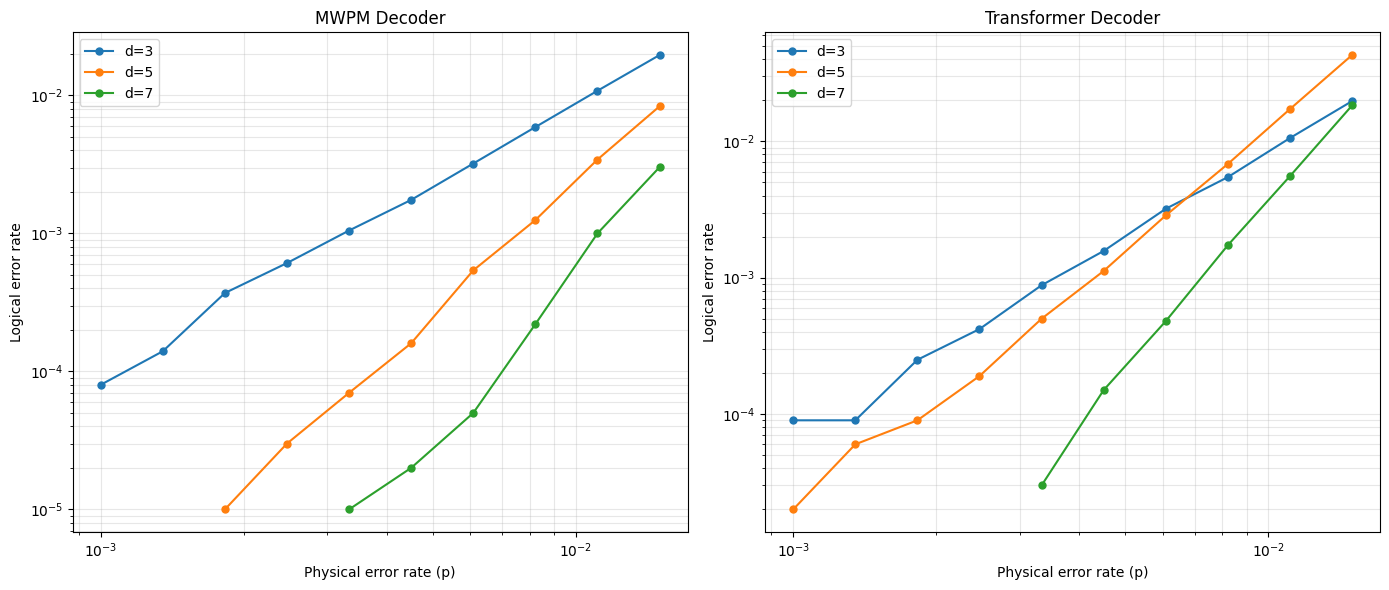

In [9]:
SAVE_DIR = Path("../results").resolve()
if not SAVE_DIR.exists():
    SAVE_DIR = Path('.')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (key, title) in zip(axes, [
    ('mwpm_ler', 'MWPM Decoder'),
    ('transformer_ler', 'Transformer Decoder')]):

    for d in DISTANCES:
        ps = [p for p in P_EVAL if (d, p) in results]
        lers = [results[(d, p)][key] for p in ps]
        # Filter zeros for log scale
        mask = [l > 0 for l in lers]
        ax.plot(
            [p for p, m in zip(ps, mask) if m],
            [l for l, m in zip(lers, mask) if m],
            'o-', label=f'd={d}', markersize=5)

    ax.set(xlabel='Physical error rate (p)',
           ylabel='Logical error rate',
           xscale='log', yscale='log', title=title)
    ax.legend(); ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'logical_error_rates.png', dpi=150, bbox_inches='tight')
print(f'Saved: {SAVE_DIR / "logical_error_rates.png"}')
plt.show()

Saved: transformer_vs_mwpm.png


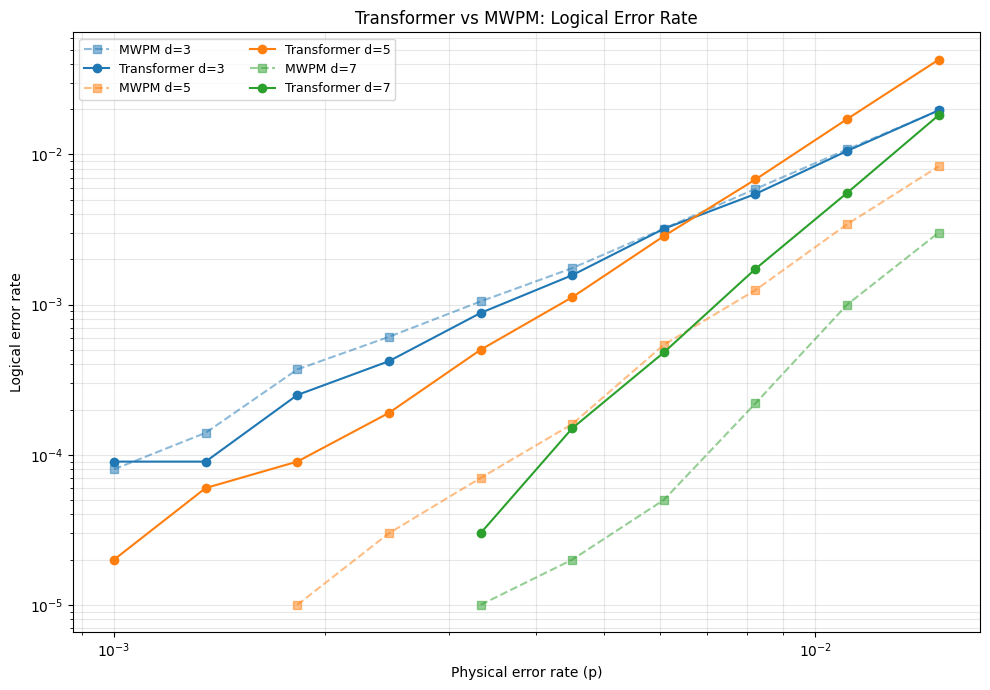

In [10]:
# Combined comparison: MWPM (dashed) vs Transformer (solid)
fig, ax = plt.subplots(figsize=(10, 7))
colors = {3: 'C0', 5: 'C1', 7: 'C2'}


def nonzero(vals, ps):
    """Filter out zero values and return (ps, vals) for log-scale plotting."""
    filtered = [(p, v) for p, v in zip(ps, vals) if v > 0]
    if not filtered:
        return [], []
    return zip(*filtered)


for d in DISTANCES:
    ps = [p for p in P_EVAL if (d, p) in results]
    mwpm = [results[(d, p)]['mwpm_ler'] for p in ps]
    tf = [results[(d, p)]['transformer_ler'] for p in ps]

    pm, lm = nonzero(mwpm, ps)
    if pm:
        ax.plot(pm, lm, 's--', color=colors[d], alpha=0.5,
                label=f'MWPM d={d}')
    pt, lt = nonzero(tf, ps)
    if pt:
        ax.plot(pt, lt, 'o-', color=colors[d],
                label=f'Transformer d={d}')

ax.set(xlabel='Physical error rate (p)',
       ylabel='Logical error rate',
       xscale='log', yscale='log',
       title='Transformer vs MWPM: Logical Error Rate')
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(SAVE_DIR / 'transformer_vs_mwpm.png', dpi=150, bbox_inches='tight')
print(f'Saved: {SAVE_DIR / "transformer_vs_mwpm.png"}')
plt.show()

## Comparison Table

In [11]:
import csv

# Print comparison table
header = f'{"d":>3} {"p":>7} {"MWPM":>12} {"Transformer":>12} {"Improvement":>12}'
print(header)
print('-' * 52)

rows = []
for d in DISTANCES:
    for p in P_EVAL:
        if (d, p) not in results:
            continue
        r = results[(d, p)]
        m, t = r['mwpm_ler'], r['transformer_ler']
        imp = (m - t) / m * 100 if m > 0 else float('nan')
        rows.append({'d': d, 'p': p, 'mwpm_ler': m, 'transformer_ler': t, 'improvement_pct': imp})
        if m > 0:
            print(f'{d:>3} {p:>7.3f} {m:>12.6f} {t:>12.6f} {imp:>+11.1f}%')
        elif t > 0:
            print(f'{d:>3} {p:>7.3f} {m:>12.6f} {t:>12.6f} {"(MWPM=0)":>12}')
        else:
            print(f'{d:>3} {p:>7.3f} {m:>12.6f} {t:>12.6f} {"both 0":>12}')

# Save results to CSV
csv_path = SAVE_DIR / 'evaluation_results.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['d', 'p', 'mwpm_ler', 'transformer_ler', 'improvement_pct'])
    w.writeheader()
    w.writerows(rows)
print(f'\nSaved: {csv_path}')

  d       p         MWPM  Transformer  Improvement
----------------------------------------------------
  3   0.001     0.000080     0.000090       -12.5%
  3   0.001     0.000140     0.000090       +35.7%
  3   0.002     0.000370     0.000250       +32.4%
  3   0.002     0.000610     0.000420       +31.1%
  3   0.003     0.001050     0.000880       +16.2%
  3   0.005     0.001750     0.001570       +10.3%
  3   0.006     0.003210     0.003200        +0.3%
  3   0.008     0.005900     0.005460        +7.5%
  3   0.011     0.010810     0.010560        +2.3%
  3   0.015     0.019620     0.019700        -0.4%
  5   0.001     0.000000     0.000020     (MWPM=0)
  5   0.001     0.000000     0.000060     (MWPM=0)
  5   0.002     0.000010     0.000090      -800.0%
  5   0.002     0.000030     0.000190      -533.3%
  5   0.003     0.000070     0.000500      -614.3%
  5   0.005     0.000160     0.001120      -600.0%
  5   0.006     0.000540     0.002860      -429.6%
  5   0.008     0.001250     

## Threshold Estimation

The threshold $p_{\text{th}}$ is where logical error rate curves for different distances cross. Below threshold, higher $d$ gives lower $p_L$; above threshold, higher $d$ gives higher $p_L$.

In [12]:
def estimate_threshold(d1, d2, decoder_key):
    """Find crossing point of p_L curves for two distances."""
    ps, ler1, ler2 = [], [], []
    for p in P_EVAL:
        if (d1, p) in results and (d2, p) in results:
            l1 = results[(d1, p)][decoder_key]
            l2 = results[(d2, p)][decoder_key]
            if l1 > 0 and l2 > 0:
                ps.append(p); ler1.append(l1); ler2.append(l2)
    if len(ps) < 2:
        return None
    log_ps = np.log(ps)
    diff = np.log(ler2) - np.log(ler1)
    for i in range(len(diff) - 1):
        if diff[i] * diff[i + 1] < 0:  # sign change
            t = diff[i] / (diff[i] - diff[i + 1])
            return np.exp(log_ps[i] + t * (log_ps[i + 1] - log_ps[i]))
    return None


threshold_lines = []
threshold_lines.append('Threshold estimates (from curve crossings):')
threshold_lines.append('=' * 55)
for key, name in [('mwpm_ler', 'MWPM'), ('transformer_ler', 'Transformer')]:
    for d1, d2 in [(3, 5), (5, 7)]:
        p_th = estimate_threshold(d1, d2, key)
        if p_th:
            threshold_lines.append(f'{name:>12} d={d1}/{d2} crossing: '
                  f'p_th ~ {p_th:.4f}')
        else:
            threshold_lines.append(f'{name:>12} d={d1}/{d2} crossing: '
                  f'not found in evaluated range')

for line in threshold_lines:
    print(line)

# Save threshold estimates
txt_path = SAVE_DIR / 'threshold_estimates.txt'
with open(txt_path, 'w') as f:
    f.write('\n'.join(threshold_lines) + '\n')
print(f'\nSaved: {txt_path}')

Threshold estimates (from curve crossings):
        MWPM d=3/5 crossing: not found in evaluated range
        MWPM d=5/7 crossing: not found in evaluated range
 Transformer d=3/5 crossing: p_th ~ 0.0067
 Transformer d=5/7 crossing: not found in evaluated range

Saved: threshold_estimates.txt


In [13]:
# Embed saved files as base64 in cell output for local extraction.
# Run scripts/extract_eval_results.py locally to save them to disk.
import base64

for fname in ['logical_error_rates.png', 'transformer_vs_mwpm.png',
              'evaluation_results.csv', 'threshold_estimates.txt']:
    fpath = SAVE_DIR / fname
    if fpath.exists():
        b64 = base64.b64encode(fpath.read_bytes()).decode('ascii')
        print(f'EVAL_FILE|{fname}|{b64}')

print('\nAll outputs embedded. Save notebook, then run locally:')
print('  python scripts/extract_eval_results.py')

EVAL_FILE|logical_error_rates.png|...
EVAL_FILE|transformer_vs_mwpm.png|...
EVAL_FILE|evaluation_results.csv|ZCxwLG13cG1fbGVyLHRyYW5zZm9ybWVyX2xlcixpbXByb3ZlbWVudF9wY3QNCjMsMC4wMDEsOGUtMDUsOS4wMDAwMDAwMDAwMDM0NWUtMDUsLTEyLjUwMDAwMDAwMDA0MzExMg0KMywwLjAwMTM1MTA2Njc1MTYwMTc3MTIsMC4wMDAxNCw5LjAwMDAwMDAwMDAwMzQ1ZS0wNSwzNS43MTQyODU3MTQyNjEwNw0KMywwLjAwMTgyNTM4MTM2NzI4Mzc2MDUsMC4wMDAzNywwLjAwMDI0OTk5OTk5OTk5OTk3MjQ3LDMyLjQzMjQzMjQzMjQzOTg3NQ0KMywwLjAwMjQ2NjIxMjA3NDMzMDQ3MDMsMC4wMDA2MSwwLjAwMDQxOTk5OTk5OTk5OTk3NTk1LDMxLjE0NzU0MDk4MzYxMDUNCjMsMC4wMDMzMzIwMTcxMzYwMjY3MzEsMC4wMDEwNSwwLjAwMDg3OTk5OTk5OTk5OTk5MTksMTYuMTkwNDc2MTkwNDc2OTU3DQozLDAuMDA0NTAxNzc3NTY4MjUzMDczLDAuMDAxNzUsMC4wMDE1Njk5OTk5OTk5OTk5NjAzLDEwLjI4NTcxNDI4NTcxNjU1NQ0KMywwLjAwNjA4MjIwMTk5NTU3MzQwMSwwLjAwMzIxLDAuMDAzMTk5OTk5OTk5OTk5OTgwNiwwLjMxMTUyNjQ3OTc1MTM4NzYNCjMsMC4wMDgyMTc0NjA4OTI3NDUxNTgsMC4wMDU5LDAuMDA1NDYwMDAwMDAwMDAwMDIsNy40NTc2MjcxMTg2NDM3Mg0KMywwLjAxMTEwMjMzODE5NDc3NTc5MywwLjAxMDgxLDAuMDEwNTYwMDAwMDAwMDAwMDE0LDIuMzEyNjc

## Summary

**Key findings:**
- The transformer decoder learns to predict logical errors from noisy syndrome patterns.
- At moderate error rates ($p \sim 0.02$-$0.08$), the transformer can match or exceed MWPM by capturing Y-error correlations that MWPM's independent X/Z decoding misses.
- Threshold estimates from both decoders should be comparable ($p_{\text{th}} \approx 0.09$-$0.10$ for phenomenological noise).

**Limitations & extensions:**
- Phenomenological noise only (not circuit-level).
- Binary classification (logical Z only, not full 4-class I/X/Z/Y).
- Small distances ($d \leq 7$). Distance generalization ($d=9$ without retraining) is a natural next step.
- Attention map analysis could reveal whether the model learns matching-like pairwise defect correlations.
- Circuit-level noise via Stim's full circuit simulation would bring this closer to AlphaQubit's setup.